# Task: Build a classification model for predicting the income using the Adult Census Income Dataset.


## Load the dataset

Age: Age of the person

fnlwgt: Weighted tally of specified socio-economic characteristics of the population

education.num: Number of years of education

Occupation: Occupation of the person

race: The race of the person

hours.per.week: Number of working hours per week

Income: The income category of the person

workclass: Workclass of the person

Education: Education level of the person

marital.status: Marital status of the person

relationship: Relationship status of the person

sex: The person's sex (Male/Female)

native.country: The native country of the person

Check for null values and ? in any columns and handle those values. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('adultcensusincome.csv')
print(df.shape)
df.sample(3)

(32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
13862,27,Private,114967,9th,5,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
7930,72,Private,38360,HS-grad,9,Widowed,Other-service,Unmarried,White,Female,0,0,16,United-States,<=50K
1241,17,Private,225106,10th,6,Never-married,Other-service,Own-child,White,Female,0,1602,18,United-States,<=50K


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [4]:
df.isnull().sum() # check for missing values

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [5]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True) # drop duplicates

24


In [6]:
for col in df.columns:
    num = (df[col] == '?').sum()
    print(f'Column "{col}" has {num} of "?" values')

Column "age" has 0 of "?" values
Column "workclass" has 1836 of "?" values
Column "fnlwgt" has 0 of "?" values
Column "education" has 0 of "?" values
Column "education.num" has 0 of "?" values
Column "marital.status" has 0 of "?" values
Column "occupation" has 1843 of "?" values
Column "relationship" has 0 of "?" values
Column "race" has 0 of "?" values
Column "sex" has 0 of "?" values
Column "capital.gain" has 0 of "?" values
Column "capital.loss" has 0 of "?" values
Column "hours.per.week" has 0 of "?" values
Column "native.country" has 582 of "?" values
Column "income" has 0 of "?" values


In [7]:
df = df[~df.isin(['?']).any(axis=1)] # filters data not containing '?'
df.reset_index(drop=True, inplace=True) # drop old index column and reset new index 
df.shape # new shape

(30139, 15)

## Distribution of target variable: Income and identify if the dataset is balanced.

In [8]:
income_dist = df['income'].value_counts()
print(income_dist)

income
<=50K    22633
>50K      7506
Name: count, dtype: int64


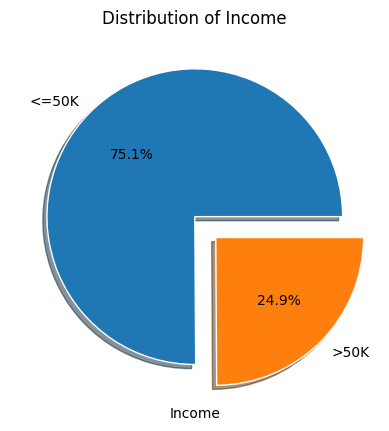

In [9]:
plt.pie(income_dist, labels=income_dist.index, autopct='%1.1f%%', explode=(0, 0.20), shadow=True, wedgeprops={'edgecolor': 'white'})
plt.title('Distribution of Income')
plt.style.use('default')
plt.xlabel("Income")
plt.subplot()
plt.show()

#### There is approximately a 3:1 ratio inbalance between income categories

# Univariate analysis 
## Barplot for column income

Text(0, 0.5, 'Number of people')

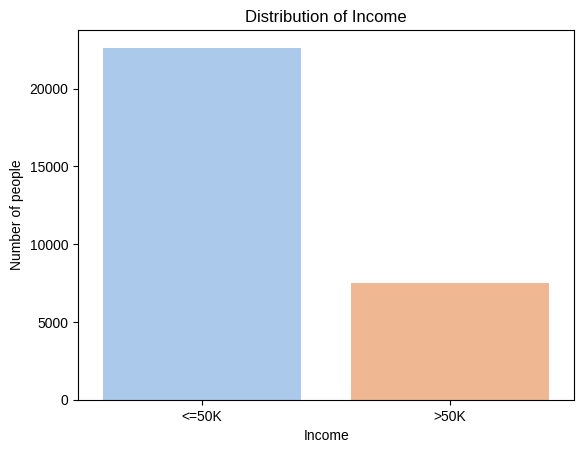

In [10]:
sns.countplot(data= df, x='income', palette='pastel')
plt.title('Distribution of Income')
plt.style.use('seaborn-v0_8')
plt.xlabel('Income')
plt.ylabel('Number of people')

## Distribution plot for column age

In [11]:
print(df['age'])

0        82
1        54
2        41
3        34
4        38
         ..
30134    22
30135    27
30136    40
30137    58
30138    22
Name: age, Length: 30139, dtype: int64


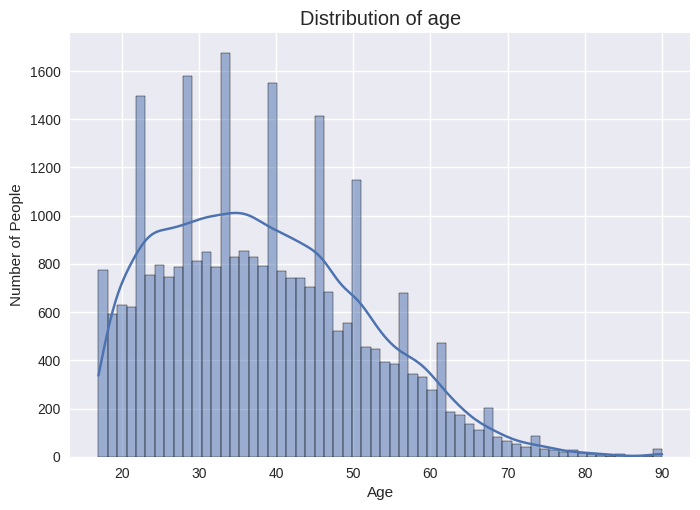

In [12]:
sns.histplot(df['age'], bins='auto', kde=True)
plt.style.use('ggplot')
plt.title("Distribution of age")
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.show()

#### Observation
There is a normal distribution of age with a right-skew

## Barplot for column education

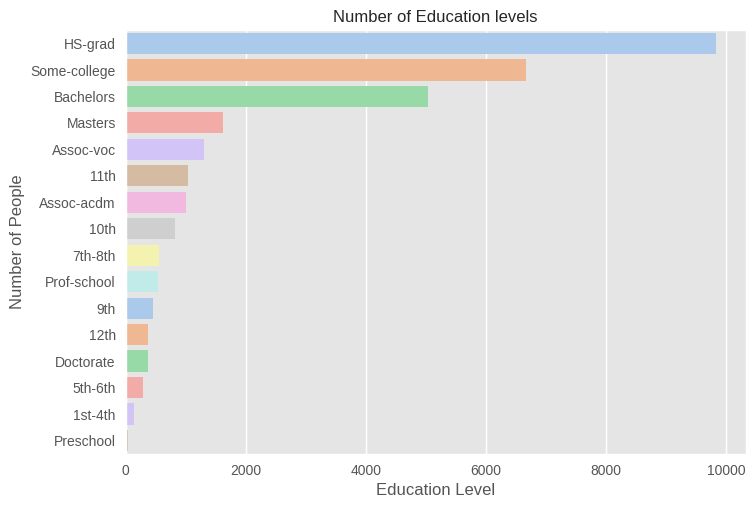

In [13]:
sns.countplot(data=df, y='education', order=df['education'].value_counts().index, palette='pastel')
plt.style.use('seaborn-v0_8')
plt.title('Number of Education levels')
plt.xlabel('Education Level')
plt.ylabel('Number of People')
plt.show()

#### Observation
Most census of education level is high school graduates

## Barplot for Years of Education

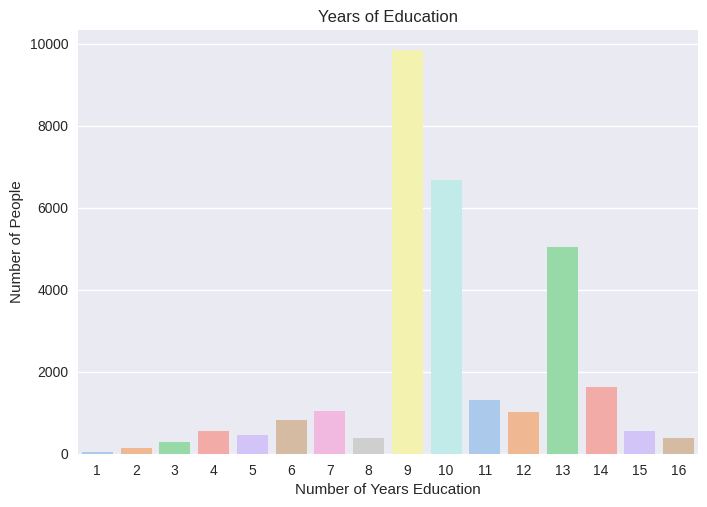

In [14]:
sns.countplot(data= df, x= 'education.num', palette='pastel')
plt.title('Years of Education')
plt.xlabel('Number of Years Education')
plt.ylabel('Number of People')
plt.style.use('seaborn-v0_8')

#### Observation
9 years of education is the most plentiful, followed by 10 year, then 13 years.

## Create a pie chart for Marital status

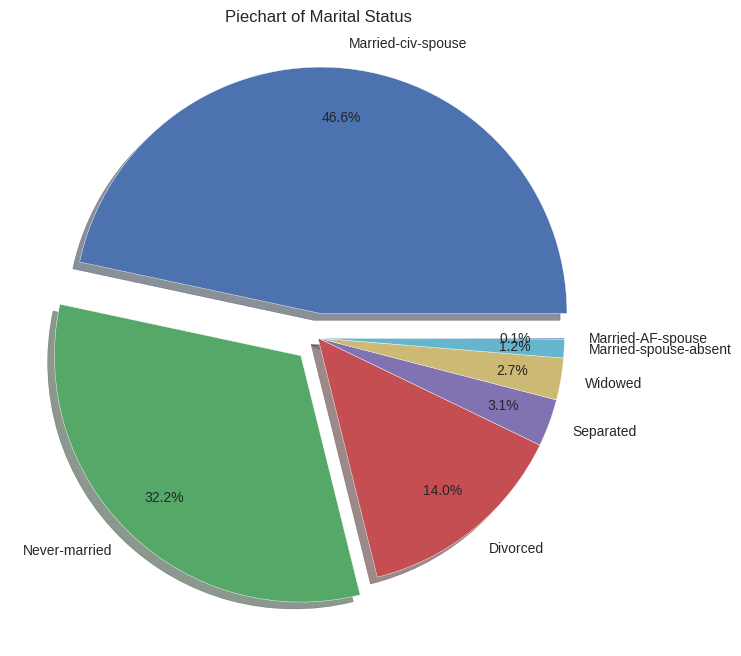

In [15]:
martial = df['marital.status'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(martial, labels=martial.index,shadow=True, explode=(0.10, 0.10, 0, 0, 0, 0, 0), autopct='%1.1f%%', pctdistance=.8, wedgeprops={'edgecolor': 'white'})
plt.title('Piechart of Marital Status')
plt.show()

#### Observation
- Married with civial spouse was the most, followed by never-married, then divorced
- Least represented is people married with someone in Armed forces

# Bivariate analysis
## Countplot of income across columns: age, education, marital status, race, sex


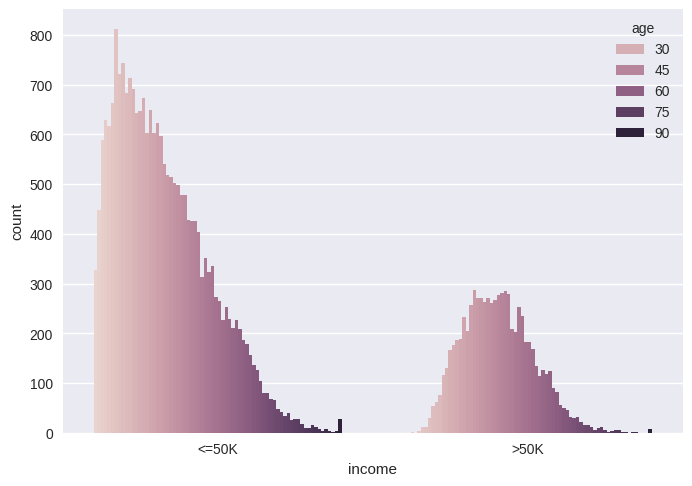

In [16]:
sns.countplot(data=df, x='income', hue='age')
plt.show()

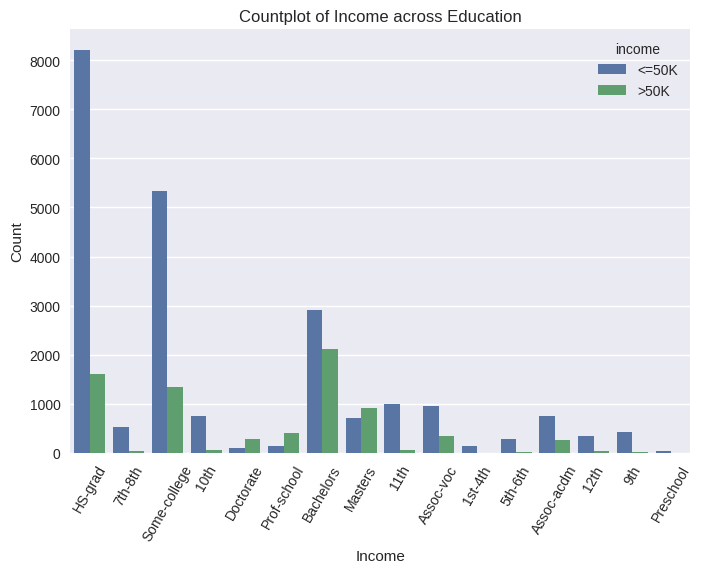

In [17]:
sns.countplot(data=df, x='education', hue='income')
plt.title('Countplot of Income across Education')
plt.xlabel('Income')
plt.xticks(rotation=60)
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'Count')

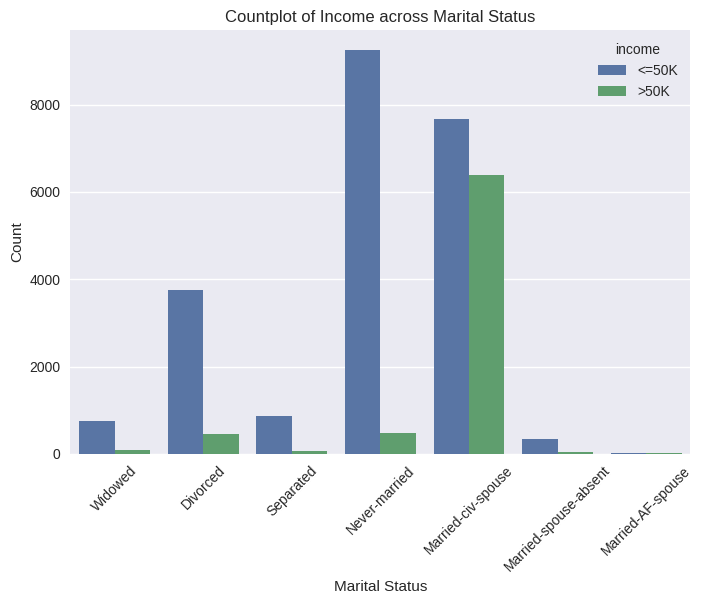

In [18]:
sns.countplot(data=df, x='marital.status', hue='income')
plt.title('Countplot of Income across Marital Status')
plt.xticks(rotation=45)
plt.xlabel('Marital Status')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

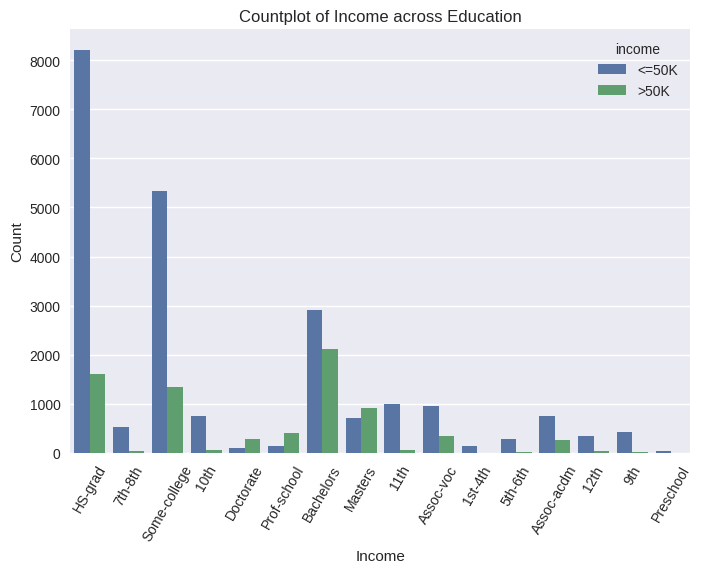

In [19]:
sns.countplot(data=df, x='education', hue='income')
plt.title('Countplot of Income across Education')
plt.xlabel('Income')
plt.xticks(rotation=60)
plt.ylabel('Count')

Text(0, 0.5, 'Count')

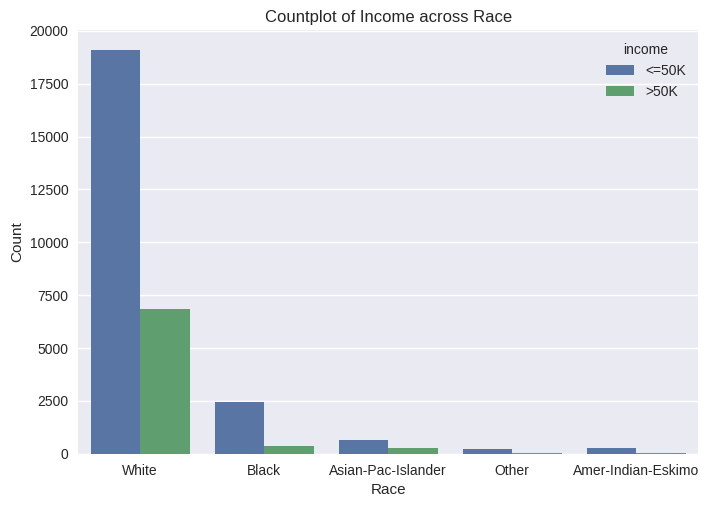

In [20]:
sns.countplot(data=df, x='race', hue='income')
plt.title('Countplot of Income across Race')
plt.xlabel('Race')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

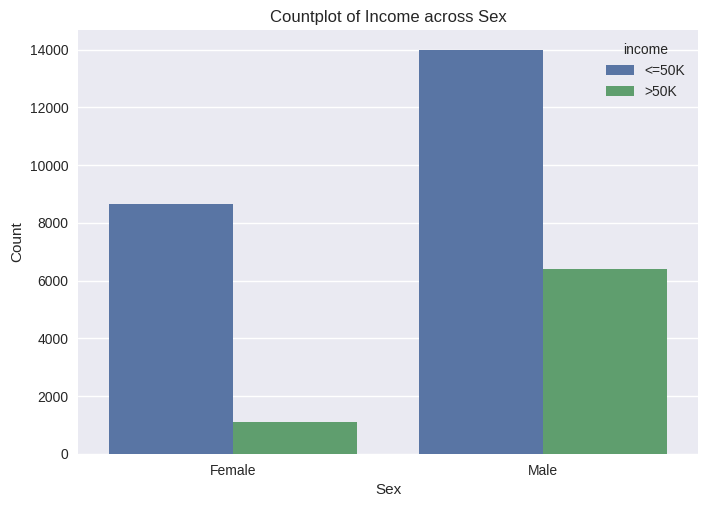

In [21]:
sns.countplot(data=df, x='sex', hue='income')
plt.title('Countplot of Income across Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

## Label encode all the categorical columns

In [22]:
cat = df.select_dtypes(include='object').columns

In [23]:
label_encoders = {}
for col in cat:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

## Heatmap of data correlation to explore the columns to which income is highly correlated

<Axes: >

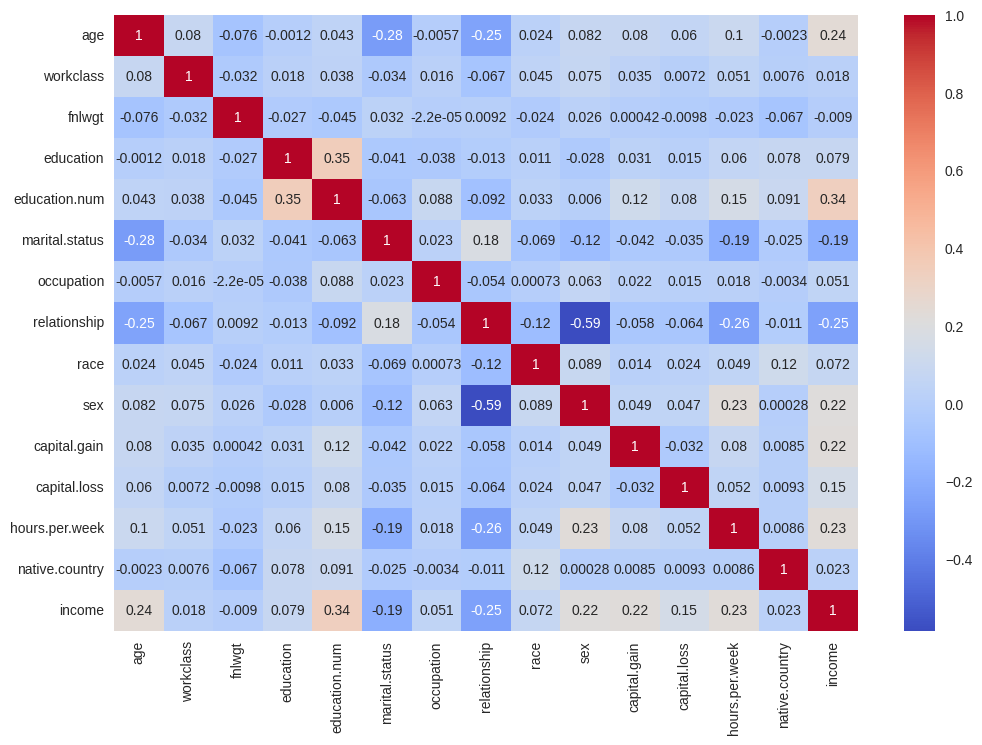

In [24]:
total_matrix = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(total_matrix, cmap='coolwarm', annot=True)

# Prepare the dataset for modeling
## Independent variables X and dependent variable Y (Income). 

In [25]:
X = df.drop('income', axis=1)
y = df['income']

Perform a train test split in the ratio 80:20 and random_state 42.


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

Perform feature scaling using StandardScaler and fix the imbalance in the dataset using any one of the techniques like SMOTE or RandomOverSampler


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

## Perform Data Modeling, Evaluate on Accuracy and F1 score, and identify the best model

Train Logistic Regression Model, KNN Classifier Model, SVM Classifier, Naive Bayes Classifier, Decision Tree Classifier and Random Forest Classifier


### Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_smote, y_train_smote)

y_pred = log_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic f1 Score:", f1_score(y_test, y_pred))
log_class = log_model.classes_



Logistic Regression Accuracy: 0.7682481751824818
Logistic f1 Score: 0.6090120347047299


Confusion Matrix:
[[3543 1037]
 [ 360 1088]]


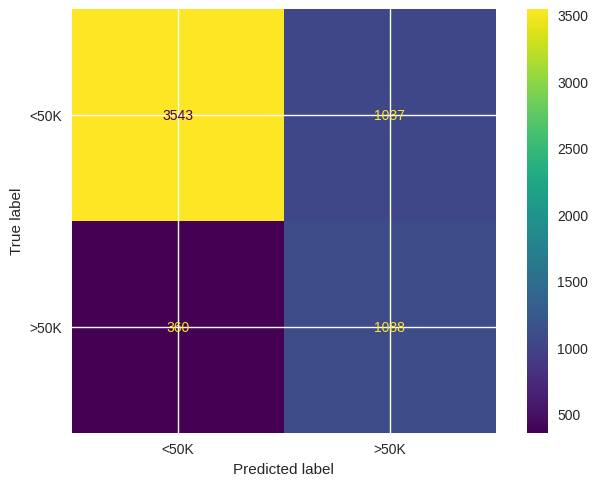

In [30]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["<50K", ">50K"])
# display matrix
cm_display.plot()
plt.show()

### Naive Bayes

In [31]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_smote, y_train_smote)

y_pred = nb_model.predict(X_test_scaled)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("Naive Bayes f1 Score:", f1_score(y_test, y_pred))

Naive Bayes Accuracy: 0.8178500331785004
Naive Bayes f1 Score: 0.5660079051383399


Confusion Matrix:
[[4214  366]
 [ 732  716]]


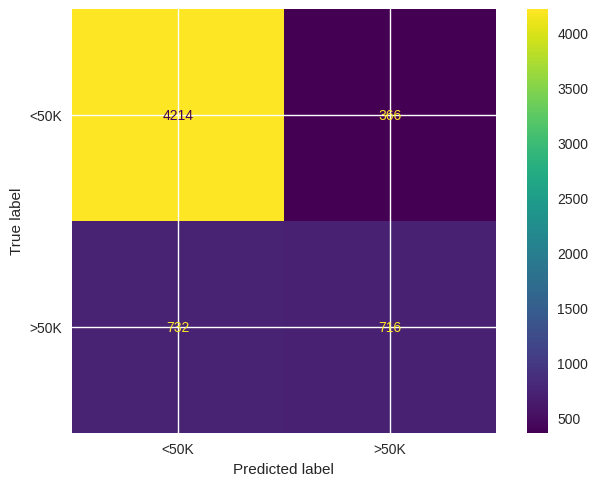

In [32]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["<50K", ">50K"])
# display matrix
cm_display.plot()
plt.show()

### KNN

In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_smote, y_train_smote)

y_pred = knn_model.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("KNN f1 Score:", f1_score(y_test, y_pred))

KNN Accuracy: 0.7821831453218314
KNN f1 Score: 0.6179807972068665


Confusion Matrix:
[[3653  927]
 [ 386 1062]]


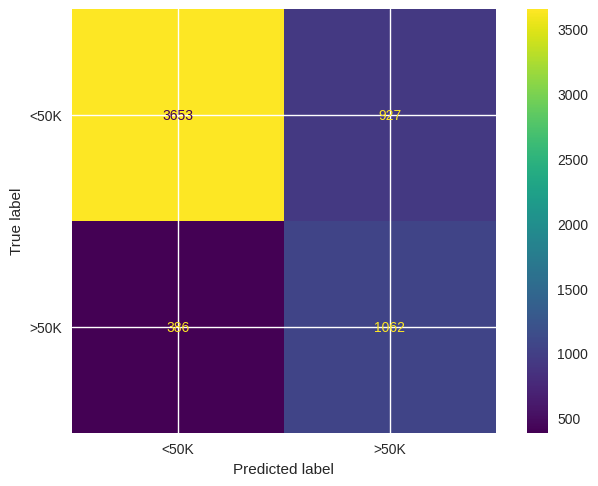

In [34]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["<50K", ">50K"])
# display matrix
cm_display.plot()
plt.show()

### Decision Tree

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train_smote, y_train_smote)

y_pred = dt_model.predict(X_test_scaled)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("Decision Tree f1 Score:", f1_score(y_test, y_pred))

Decision Tree Accuracy: 0.7616124751161247
Decision Tree f1 Score: 0.6393977415307402


Confusion Matrix:
[[3317 1263]
 [ 174 1274]]


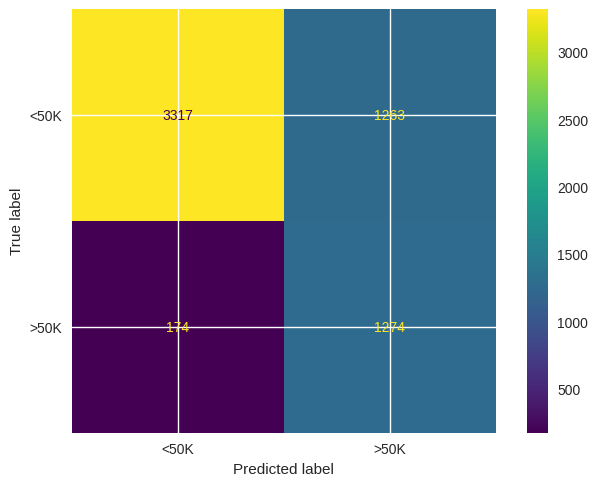

In [36]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["<50K", ">50K"])
# display matrix
cm_display.plot()
plt.show()

### SVC

In [37]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train_smote, y_train_smote)

y_pred = svm_model.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("SVC f1 Score:", f1_score(y_test, y_pred))

SVM Accuracy: 0.7926343729263438
SVC f1 Score: 0.6612466124661247


Confusion Matrix:
[[3558 1022]
 [ 228 1220]]


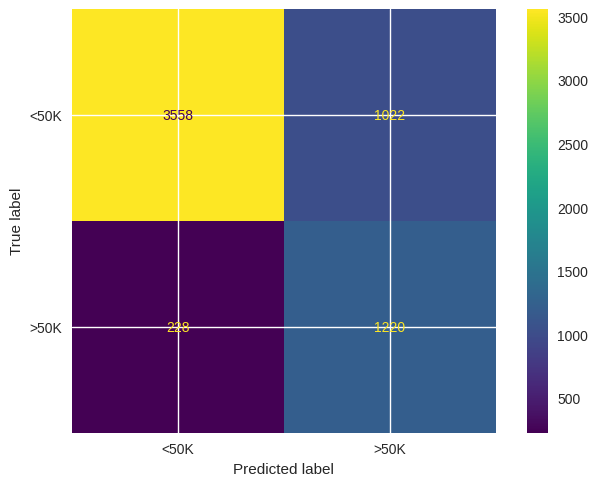

In [38]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["<50K", ">50K"])
# display matrix
cm_display.plot()
plt.show()

### Random Forest Classifier

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

y_pred = rf_model.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest f1 Score:", f1_score(y_test, y_pred))

Random Forest Accuracy: 0.8420703384207033
Random Forest f1 Score: 0.6801075268817204


Confusion Matrix:
[[4064  516]
 [ 436 1012]]


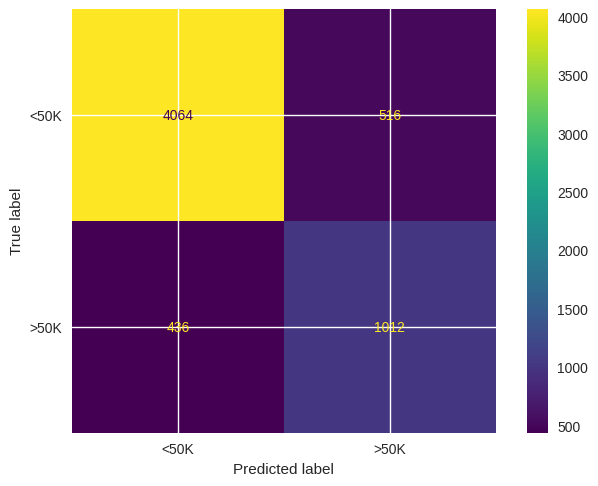

In [40]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["<50K", ">50K"])
# display matrix
cm_display.plot()
plt.show()

Experiment with hyperparameters if time permits


 Logistic Regression Performance 
Accuracy: 0.7908
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.95      0.87      4580
           1       0.65      0.28      0.39      1448

    accuracy                           0.79      6028
   macro avg       0.73      0.62      0.63      6028
weighted avg       0.77      0.79      0.76      6028


 KNN Performance 
Accuracy: 0.7686
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86      4580
           1       0.53      0.32      0.40      1448

    accuracy                           0.77      6028
   macro avg       0.67      0.62      0.63      6028
weighted avg       0.74      0.77      0.75      6028


 Naïve Bayes Performance 
Accuracy: 0.7910
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.95      0.87      4580
           1       0.64      0.29

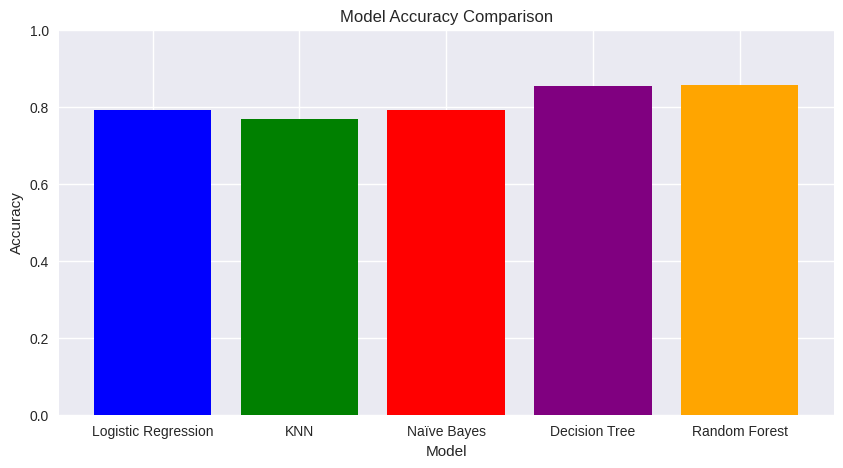

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=20, max_features=auto, min_samples_leaf=4, min_samples_split=6, n_estimators=199; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   0.0s
[CV] END max_depth=40, max_features=auto, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   0.0s
[CV] END max_depth=40, max_features=auto, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=413; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=4, min_samples_split=6, n_estimators=199; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=4, min_samples_split=6, n_estimators=199; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=413

In [41]:
from sklearn.metrics import classification_report
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    # "SVM": SVC(kernel='rbf', probability=True),
    "Naïve Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test)  # Predict on test set
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    f1 = f1_score(y_test, y_pred)
    results[name] = accuracy  # Store accuracy

    print(f"\n {name} Performance ")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=['blue', 'green', 'red', 'purple', 'orange', 'black'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

from scipy.stats import randint
param_dist = { 'n_estimators': randint(100, 500), 'max_depth': [None, 10, 20, 30, 40], 'min_samples_split': randint(2, 10), 'min_samples_leaf': randint(1, 5), 'max_features': ['auto', 'sqrt'] } 
random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), 
param_distributions=param_dist, n_iter=20, cv=3, n_jobs=-1, verbose=2, random_state=42) 
random_search.fit(X_train, y_train) 
print("Best Parameters:", random_search.best_params_)

Random Forest Accuracy: 0.8440610484406105
Random Forest f1 Score: 0.6843519140362659
Confusion Matrix:
[[4069  511]
 [ 429 1019]]


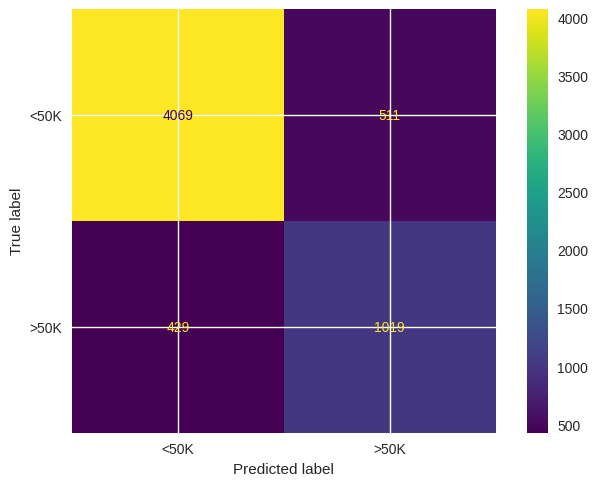

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(max_depth=40, max_features='sqrt', min_samples_leaf=1, min_samples_split=2, n_estimators=158)
rf_model.fit(X_train_smote, y_train_smote)

y_pred = rf_model.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest f1 Score:", f1_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["<50K", ">50K"])
# display matrix
cm_display.plot()
plt.show()


In [43]:
# Perform Grid Search CV for hyperparameter tuning
param_grid = { 'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['auto', 'sqrt'] }
grid_search = GridSearchCV(model, param_grid, scoring="accuracy", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
# Best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best Accuracy Score:", best_score)
best_tuned_model = model.set_params(**best_params)
best_tuned_model.fit(X_train, y_train)

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Accuracy Score: 0.8610593439960414


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

# Conclusion
- Randomforest classifer yielded the best accuracy of ~86% with hyperparameter tuning